# Primordial abundances vs neutrino degeneracy parameter ξ

## Physical background

A non-zero neutrino chemical potential $\mu_\nu$ (often called **neutrino degeneracy**)
modifies the Fermi-Dirac distribution of neutrinos and anti-neutrinos:
$$
f_\nu(E) = \frac{1}{e^{(E-\mu_\nu)/T_\nu}+1}, \qquad
f_{\bar\nu}(E) = \frac{1}{e^{(E+\mu_\nu)/T_\nu}+1}.
$$
The dimensionless degeneracy parameter is $\xi \equiv \mu_\nu / T_\nu$.

A positive $\xi$ (more neutrinos than anti-neutrinos) has two effects at BBN:

1. **Direct (chemical potential) effect** — $\nu_e$ drives the n↔p equilibrium
   toward protons (n + ν_e → p + e⁻ is enhanced), **lowering $Y_P$**.

2. **Indirect (energy density) effect** — extra neutrinos increase the Hubble rate,
   which tends to **raise $Y_P$** (as in ΔNeff > 0).

For electron neutrinos the direct effect dominates: $Y_P$ decreases with $\xi > 0$.
Deuterium is also affected through the changed neutron-to-proton ratio.

In PRIMAT, ξ is controlled by the `munuOverTnu` parameter
(= $\mu_\nu / T_\nu$, assumed equal for all three flavours).

## What this notebook does

We scan $\xi$ from $-0.05$ to $+0.05$ (the range allowed by BBN+CMB constraints)
and compute YP and D/H at each point with 1σ nuclear-rate uncertainty bands.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import multiprocessing

from primat.backend import run_mc

**Note on backends.** `run_mc`'s results are recoverable identically from either the C or the pure-Python backend: both return the same `MCResult` shape (`mc['key'].mean`/`.std`/`.values`/`.central`, `mc.quantity_names()`, `mc.samples_array()`). Samples are *statistically* (not bit-for-bit) comparable between backends -- the C backend draws with a pthread/xoshiro256** RNG, the Python backend with joblib/numpy's `default_rng` -- so the same seed will not reproduce identical sample values across backends, only matching means/stds at large `num_mc`. Per-sample TSV export is available via `primat.backend.dump_mc_samples(mc)`.


In [2]:
# ---------------------------------------------------------------------------
# Grid and options
# ---------------------------------------------------------------------------

# ξ grid: from -0.05 to +0.05 in steps of 0.01
xi_vec  = np.arange(-0.05, 0.051, 0.01)
npoints = len(xi_vec)

num_mc  = 100     # MC samples per grid point (use ≥100 for publication quality)
num_cpu = multiprocessing.cpu_count()
MC_SEED = 0      # Fixed seed — correlated MC bias across the grid

base_opts = {
    'Omegabh2':          0.02285,
}

print(f"Grid: {npoints} ξ values from {xi_vec[0]:.2f} to {xi_vec[-1]:.2f}")
print(f"MC samples per point: {num_mc}  |  CPUs: {num_cpu}")

Grid: 11 ξ values from -0.05 to 0.05
MC samples per point: 100  |  CPUs: 8


In [3]:
# ---------------------------------------------------------------------------
# Compute central values and MC uncertainty at each ξ
# ---------------------------------------------------------------------------
# `munuOverTnu` is the PRIMAT parameter for ξ = μ_ν/T_ν.
# It is assumed to be the same for all three neutrino flavours.

quantities = ['YPBBN', 'DoH', 'He3oH', 'Li7oH']

cen = {q: np.zeros(npoints) for q in quantities}
err = {q: np.zeros(npoints) for q in quantities}

for i, xi in enumerate(xi_vec):
    print(f"  ξ = {xi:+.3f}  ({i+1}/{npoints})", flush=True)
    opts = {**base_opts, 'munuOverTnu': float(xi)}
    mc = run_mc(num_mc, quantities, params=opts,
                n_jobs=num_cpu, seed=MC_SEED)
    for q in quantities:
        cen[q][i] = mc[q].central
        err[q][i] = mc[q].std

print("Done.")

  ξ = -0.050  (1/11)
  ξ = -0.040  (2/11)
  ξ = -0.030  (3/11)
  ξ = -0.020  (4/11)
  ξ = -0.010  (5/11)
  ξ = +0.000  (6/11)
  ξ = +0.010  (7/11)
  ξ = +0.020  (8/11)
  ξ = +0.030  (9/11)
  ξ = +0.040  (10/11)
  ξ = +0.050  (11/11)
Done.


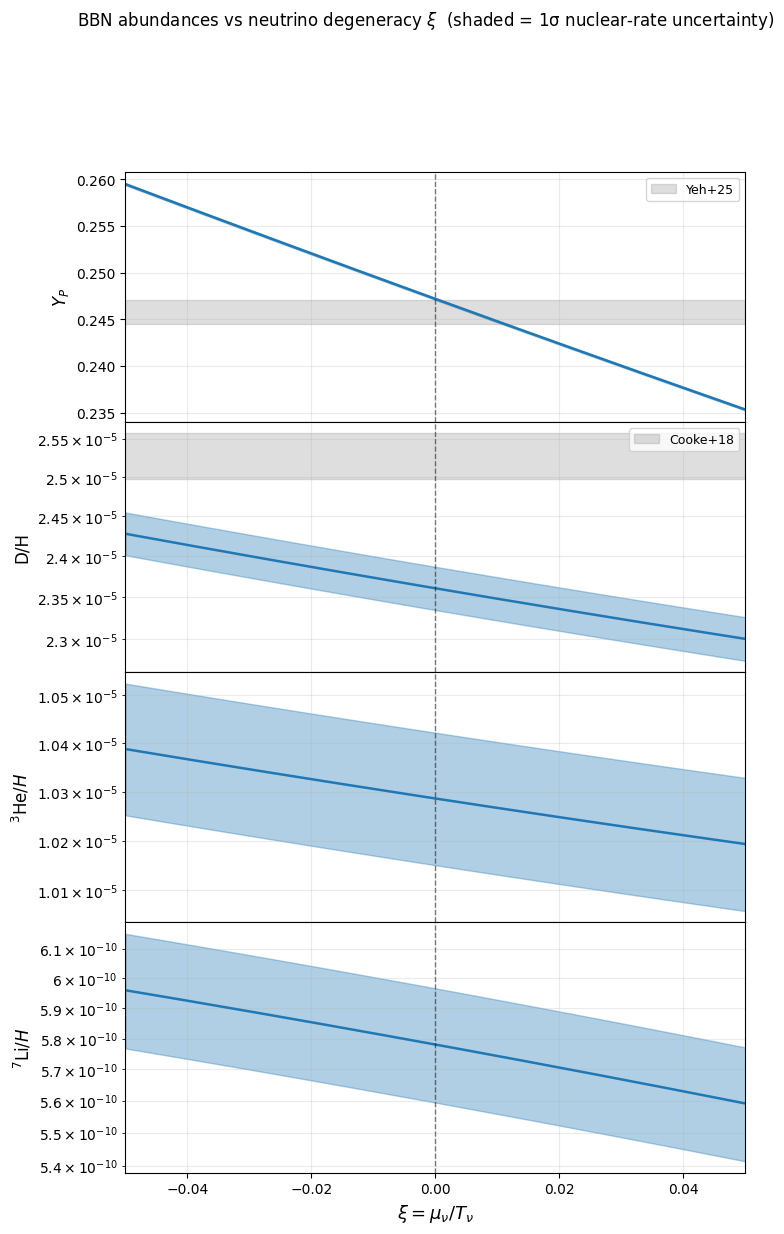

Saved plots/abundances_Xi.pdf


In [4]:
# ---------------------------------------------------------------------------
# Plot: abundances vs ξ
# ---------------------------------------------------------------------------
# The most sensitive observables are YP (strong direct effect) and D/H
# (through the changed n/p ratio).  He3 and Li7 are shown for completeness.

x     = xi_vec
xfine = np.linspace(x[0], x[-1], 300)

def smooth(y):
    return interp1d(x, y, kind='cubic')(xfine)

# Observational constraints
YP_obs,  YP_obs_err  = 0.2458,   0.0013      # Yeh et al. 2025
DoH_obs, DoH_obs_err = 2.527e-5, 0.030e-5    # Cooke et al. 2018

panel_info = [
    ('YPBBN', r'$Y_P$',           False, YP_obs,  YP_obs_err,  'Yeh+25'),
    ('DoH',   r'D/H',             True,  DoH_obs, DoH_obs_err, 'Cooke+18'),
    ('He3oH', r'$^3{\rm He}/H$',  True,  None,    None,        None),
    ('Li7oH', r'$^7{\rm Li}/H$',  True,  None,    None,        None),
]

c_th  = 'tab:blue'
c_obs = 'tab:gray'

fig, axs = plt.subplots(4, 1, figsize=(8, 13), sharex=True)
fig.subplots_adjust(hspace=0)

for ax, (key, ylabel, log, obs_val, obs_err, obs_label) in zip(axs, panel_info):
    ax.fill_between(xfine,
                    smooth(cen[key] - err[key]),
                    smooth(cen[key] + err[key]),
                    alpha=0.35, color=c_th)
    ax.plot(xfine, smooth(cen[key]), color=c_th, lw=1.8)

    if obs_val is not None:
        ax.axhspan(obs_val - obs_err, obs_val + obs_err,
                   alpha=0.25, color=c_obs, label=obs_label)
        ax.legend(fontsize=9, loc='upper right')

    ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)  # SM: ξ = 0
    ax.set_ylabel(ylabel, fontsize=12)
    if log:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=10)

axs[-1].set_xlabel(r'$\xi = \mu_\nu / T_\nu$', fontsize=13)
for ax in axs:
    ax.set_xlim(x[0], x[-1])

fig.suptitle(r'BBN abundances vs neutrino degeneracy $\xi$  '
             r'(shaded = 1σ nuclear-rate uncertainty)', fontsize=12, y=1.005)
plt.savefig('plots/abundances_Xi.pdf', bbox_inches='tight')
plt.show()
print("Saved plots/abundances_Xi.pdf")